In [1]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt

In [3]:
def dms_to_decimal(value):
    import re
    try:
        return float(value)
    except ValueError:
        pass
    
    parts = re.findall(r'\d+', str(value))
    if len(parts) == 3:
        degrees, minutes, seconds = map(float, parts)
        return degrees + minutes/60 + seconds/3600
    else:
        raise ValueError(f"Formato DMS non valido: {value}")

--------------------------
### Import metadata

In [ ]:
df = pd.read_csv("../Meta/Aedes Tabella genotipizzazione alleli resistenza totale_27062025.csv", sep = ";")
df.head()

In [4]:
df.columns

Index(['Codice Esemplare', 'Ente', 'Responsabile', 'regione', 'Province',
       'Comune', 'Site', 'Lat', 'Long', 'Lat_Long', 'Anno campionamento',
       'Mese di campionamento', 'Metodo di Cattura', 'Stadio Genotipizzato',
       'V1016G (PCR)', 'F1534C (PCR)', 'Disponibilità Info Trattamento',
       'Note su trattamenti', 'Disponibilità carcassa/DNA', 'Unnamed: 19',
       'Unnamed: 20'],
      dtype='object')

In [6]:
df['lat_decimal'] = df['Lat'].apply(dms_to_decimal)
df['long_decimal'] = df['Long'].apply(dms_to_decimal)
geometry = [Point(xy) for xy in zip(df['long_decimal'], df['lat_decimal'])]
gdf_points = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

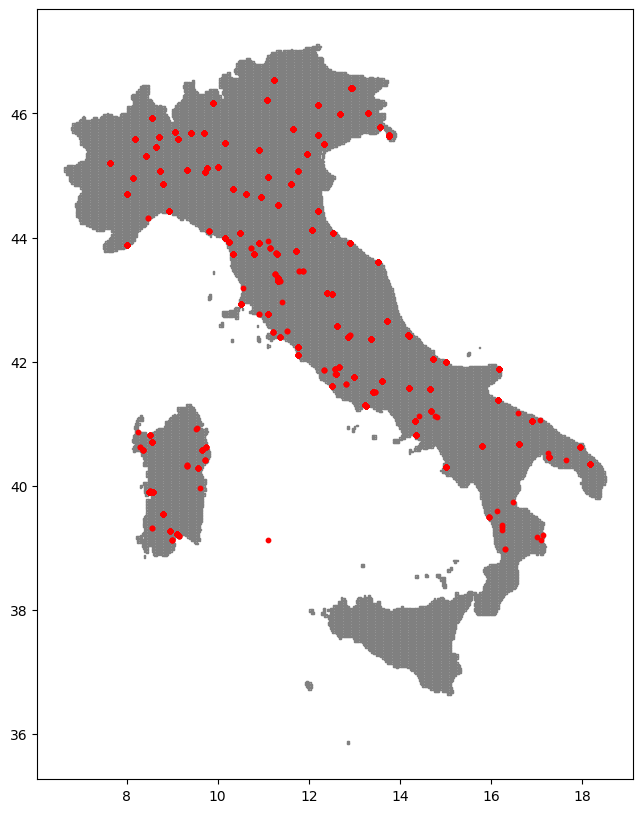

In [7]:
gdf_grid = gpd.read_file('/media/randomx/Data/Gis/shape/grid_italy.shp') #grid

gdf_points = gdf_points.to_crs(gdf_grid.crs)

fig, ax = plt.subplots(figsize=(10, 10))

gdf_grid.plot(ax=ax, facecolor='none', edgecolor='gray')

gdf_points.plot(ax=ax, color='red', markersize=10)

plt.show()

In [8]:
gdf_points = gdf_points.to_crs(gdf_grid.crs)

In [9]:
gdf_joined = gpd.sjoin(gdf_points, gdf_grid, how='left', predicate='within')

In [10]:
gdf_grid['centroid'] = gdf_grid.centroid

/tmp/ipykernel_29730/1562702694.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_grid['centroid'] = gdf_grid.centroid


In [11]:
gdf_joined = gdf_joined.merge(
    gdf_grid[['centroid','GID_2']],
    left_on='index_right',
    right_index=True,
    how='left'
)
gdf_joined.head()
gdf_joined['geometry'] = gdf_joined['centroid']
gdf_joined['longitude_masked'] = gdf_joined.geometry.x
gdf_joined['latitude_masked'] = gdf_joined.geometry.y
gdf_joined.head()

,Codice Esemplare,Ente,Responsabile,regione,Province,Comune,Site,Lat,Long,Lat_Long,...,TYPE_3,ENGTYPE_3,CC_3,HASC_3,cent_text,TigacellID,centroid,GID_2_y,longitude_masked,latitude_masked
0,1_CH_Ae_24,IZSAM,Di Domenico,Abruzzo,CHIETI,SAN GIOVANNI TEATINO,VIA-ANTENNE,42.413718,14.202405,42.4137181 14.2024047,...,Commune,Commune,NA,IT.CH.CH,POINT (14.2 42.425),14.2_42.425,POINT (14.2 42.425),ITA.1.1_1,14.2,42.425
1,2_CH_Ae_24,IZSAM,Di Domenico,Abruzzo,CHIETI,SAN GIOVANNI TEATINO,VIA-ANTENNE,42.413718,14.202405,42.4137181 14.2024047,...,Commune,Commune,NA,IT.CH.CH,POINT (14.2 42.425),14.2_42.425,POINT (14.2 42.425),ITA.1.1_1,14.2,42.425
2,3_CH_Ae_24,IZSAM,Di Domenico,Abruzzo,CHIETI,SAN GIOVANNI TEATINO,VIA-ANTENNE,42.413718,14.202405,42.4137181 14.2024047,...,Commune,Commune,NA,IT.CH.CH,POINT (14.2 42.425),14.2_42.425,POINT (14.2 42.425),ITA.1.1_1,14.2,42.425
3,4_CH_Ae_24,IZSAM,Di Domenico,Abruzzo,CHIETI,SAN GIOVANNI TEATINO,VIA-ANTENNE,42.413718,14.202405,42.4137181 14.2024047,...,Commune,Commune,NA,IT.CH.CH,POINT (14.2 42.425),14.2_42.425,POINT (14.2 42.425),ITA.1.1_1,14.2,42.425
4,5_CH_Ae_24,IZSAM,Di Domenico,Abruzzo,CHIETI,SAN GIOVANNI TEATINO,VIA-ANTENNE,42.413718,14.202405,42.4137181 14.2024047,...,Commune,Commune,NA,IT.CH.CH,POINT (14.2 42.425),14.2_42.425,POINT (14.2 42.425),ITA.1.1_1,14.2,42.425


In [12]:
len(gdf_joined), len(df)

(2850, 2850)

-------------------------------------------------
## Calcolo stats per cella

In [13]:
df = gdf_joined

In [14]:
df['V1016G (PCR)'] = df['V1016G (PCR)'].astype(str).str.strip().str.upper()
df['F1534C (PCR)'] = df['F1534C (PCR)'].astype(str).str.strip().str.upper()

def count_genotypes(series):
    counts = series.value_counts()
    result = {gt: counts.get(gt, 0) for gt in ['GG', 'VG', 'VV']}
    result['N'] = sum(result.values())
    return pd.Series(result)

def map_1534_genotypes(val):
    if pd.isna(val):
        return None
    val = val.strip().upper()
    if val == 'FF' or val == 'FF (SEQ)':
        return 'VV'
    elif val == 'FC':
        return 'VG'
    elif val == 'CC':
        return 'GG'
    else:
        return None  # valori inattesi o da scartare

df['F1534C_mapped'] = df['F1534C (PCR)'].apply(map_1534_genotypes)

grp_1534 = df.groupby(['longitude_masked','latitude_masked'])['F1534C_mapped'].apply(count_genotypes).unstack(fill_value=0).reset_index()

grp_1534['C%_1534'] = ((grp_1534['GG'] * 2) + grp_1534['VG']) / (grp_1534['N'] * 2)
grp_1534['C%_1534'] = grp_1534['C%_1534'].round(3)

grp_1016 = df.groupby(['longitude_masked','latitude_masked'])['V1016G (PCR)'].apply(count_genotypes).unstack(fill_value=0).reset_index()
grp_1016['G%_1016'] = ((grp_1016['GG'] * 2) + grp_1016['VG']) / (grp_1016['N'] * 2)
grp_1016['G%_1016'] = grp_1016['G%_1016'].round(3)

result = pd.merge(grp_1016, grp_1534, on=['longitude_masked','latitude_masked'], suffixes=('_1016', '_1534'))
result = result.reset_index()
result.head()

,index,longitude_masked,latitude_masked,GG_1016,VG_1016,VV_1016,N_1016,G%_1016,GG_1534,VG_1534,VV_1534,N_1534,C%_1534
0,0,7.650,45.200,0,0,30,30,0.000,0,0,30,30,0.0
1,1,8.025,43.875,0,0,18,18,0.000,0,0,16,16,0.0
2,2,8.025,44.700,0,4,26,30,0.067,0,0,30,30,0.0
3,3,8.125,44.950,0,0,8,8,0.000,0,0,8,8,0.0
4,4,8.200,45.575,0,0,12,12,0.000,0,0,12,12,0.0


In [15]:

extra_cols = ['Site','Comune', 'Ente', 'Responsabile', 'regione', 'Province', 'Anno campionamento','Lat','Long','longitude_masked','latitude_masked', 'Mese di campionamento','Metodo di Cattura','Stadio Genotipizzato','GID_2_y']
extra_info = df[extra_cols].drop_duplicates(subset=['longitude_masked','latitude_masked'])

final_df = pd.merge(result, extra_info, on=['longitude_masked','latitude_masked'], how='left')

final_df = final_df[['Site','Comune', 'N_1016', 'GG_1016', 'VG_1016', 'VV_1016', 'G%_1016',
                     'N_1534', 'GG_1534', 'VG_1534', 'VV_1534', 'C%_1534','Ente',
                     'Responsabile', 'regione', 'Province', 'Anno campionamento','Lat','Long',
                     'longitude_masked','latitude_masked','Mese di campionamento',
                     'Metodo di Cattura','Stadio Genotipizzato','GID_2_y']].rename(columns={'GID_2_y':'GID_2', 'Comune':'Comune','regione':'Regione', 'Province':'Provincia'})
final_df

,Site,Comune,N_1016,GG_1016,VG_1016,VV_1016,G%_1016,N_1534,GG_1534,VG_1534,...,Provincia,Anno campionamento,Lat,Long,longitude_masked,latitude_masked,Mese di campionamento,Metodo di Cattura,Stadio Genotipizzato,GID_2
0,Aeroporto,CASELLE,30,0,0,30,0.000,30,0,0,...,Torino,2024.0,45.193170,7.643180,7.650,45.200,settembre,ovitrappola,adulto,ITA.13.6_1
1,IMPERIA,IMPERIA,18,0,0,18,0.000,16,0,0,...,Imperia,2024.0,43.885390,8.013910,8.025,43.875,NaN,NaN,adulto,ITA.9.2_1
2,Orti c/o cimitero,ALBA,30,0,4,26,0.067,30,0,0,...,Cuneo,2024.0,44.696500,8.020190,8.025,44.700,agosto-settembre,CDC-CO2,adulto,ITA.13.4_1
3,fraz. Mombarone,ASTI,8,0,0,8,0.000,8,0,0,...,Asti,2024.0,44.958300,8.137000,8.125,44.950,agosto-settembre,CDC-CO2,adulto,ITA.13.2_1
4,Villa Boggio,LESSONA,12,0,0,12,0.000,12,0,0,...,Biella,2024.0,45.583600,8.194700,8.200,45.575,agosto-settembre,CDC-CO2,adulto,ITA.13.3_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,sito rurale,Taranto,1,0,0,1,0.000,1,0,0,...,Taranto,2024.0,40.531898,17.251351,17.250,40.525,luglio,Sì,Adulti,ITA.2.6_1
158,Villa privata,Taranto,10,2,3,5,0.350,10,0,0,...,Taranto,2025.0,40.463595,17.268182,17.275,40.475,maggio,Sì,Adulti,ITA.2.6_1
159,sito rurale,Manduria,1,0,0,1,0.000,1,0,0,...,Taranto,2024.0,40.423841,17.630895,17.625,40.425,luglio,Sì,Adulti,ITA.2.6_1
160,Villa privata,Brindisi,9,1,4,4,0.333,9,0,0,...,Brindisi,2025.0,40.630998,17.942877,17.950,40.625,maggio,Sì,Adulti,ITA.2.3_1


In [16]:
final_df.to_csv("../Meta/albo_geno_masked.csv")

------------------------------------------
### sistemo dati

In [86]:
df = final_df

In [87]:
import pandas as pd

mese_mapping = {
    1: 'Gennaio', 2: 'Febbraio', 3: 'Marzo', 4: 'Aprile',
    5: 'Maggio', 6: 'Giugno', 7: 'Luglio', 8: 'Agosto',
    9: 'Settembre', 10: 'Ottobre', 11: 'Novembre', 12: 'Dicembre',
    'gennaio': 'Gennaio', 'febbraio': 'Febbraio', 'marzo': 'Marzo', 'aprile': 'Aprile',
    'maggio': 'Maggio', 'giugno': 'Giugno', 'luglio': 'Luglio', 'agosto': 'Agosto',
    'settembre': 'Settembre', 'ottobre': 'Ottobre', 'novembre': 'Novembre', 'dicembre': 'Dicembre',
    'LUGLIO': 'Luglio', 'Luglio': 'Luglio', 'AGOSTO': 'Agosto', 'agosto': 'Agosto',
    'Settembre': 'Settembre', 'settembre': 'Settembre', 'Ottobre': 'Ottobre', 'ottobre': 'Ottobre',
    'Giugno': 'Giugno', 'giugno': 'Giugno',
    'agosto-settembre': 'Agosto-Settembre',
}

from dateutil import parser

def normalizza_mese(val):
    if pd.isna(val):
        return None

    if isinstance(val, pd.Timestamp):
        return mese_mapping.get(val.month, f'Mese {val.month}')

    elif isinstance(val, (int, float)):
        return mese_mapping.get(int(val), f'Mese {int(val)}')

    elif isinstance(val, str):
        val_clean = val.strip().lower()

        try:
            parsed_date = parser.parse(val)
            return mese_mapping.get(parsed_date.month, f'Mese {parsed_date.month}')
        except Exception:
            return mese_mapping.get(val_clean, val.strip().capitalize())

    return str(val)


df['Mese di campionamento'] = df['Mese di campionamento'].apply(normalizza_mese)

In [88]:
mapping_comuni = {
    'CASELLE': 'Caselle',
    'IMPERIA': 'Imperia',
    'ALBA': 'Alba',
    'ASTI': 'Asti',
    'LESSONA': 'Lessona',
    'Stintino': 'Stintino',
    'Alghero': 'Alghero',
    'VERCELLI': 'Vercelli',
    'SAVONA': 'Savona',
    'Oristano': 'Oristano',
    'Sorso': 'Sorso',
    'Cabras': 'Cabras',
    'Sassari': 'Sassari',
    'VERBANIA': 'Verbania',
    'Iglesias': 'Iglesias',
    'NOVARA': 'Novara',
    'MERATE': 'Merate',
    'MALPENSA': 'Malpensa',
    'San Gavino': 'San Gavino',
    'RIVALTA SCRIVIA': 'Rivalta Scrivia',
    'GENOVA': 'Genova',
    'Uta': 'Uta',
    'Capoterra': 'Capoterra',
    'CERMENATE': 'Cermenate',
    'Cagliari': 'Cagliari',
    'LIMBIATE': 'Limbiate',
    'Nuoro': 'Nuoro',
    'STRADELLA': 'Stradella',
    'MILANO': 'Milano',
    'Olbia': 'Olbia',
    'Dorgali': 'Dorgali',
    'Bari Sardo': 'Bari Sardo',
    'Siniscola': 'Siniscola',
    'BERGAMO': 'Bergamo',
    'PIACENZA': 'Piacenza',
    'Orosei': 'Orosei',
    'Posada': 'Posada',
    'CASELLE LANDI': 'Caselle Landi',
    'LA SPEZIA': 'La Spezia',
    'SONDRIO': 'Sondrio',
    'CREMONA': 'Cremona',
    'Montignoso': 'Montignoso',
    'BRESCIA': 'Brescia',
    'San_Giuliano_terme': 'San Giuliano Terme',
    'PARMA': 'Parma',
    'REGGIO EMILIA': 'Reggio Emilia',
    'Fucecchio': 'Fucecchio',
    'Castiglione_della_Pescaia': 'Castiglione della Pescaia',
    'MODENA': 'Modena',
    'POGGIO RUSCO': 'Poggio Rusco',
    'Campi_bisenzio': 'Campi Bisenzio',
    'Firenze': 'Firenze',
    'Bagno_a_ripoli': 'Bagno a Ripoli',
    'BOLOGNA': 'Bologna',
    'Capalbio': 'Capalbio',
    'Cingiano ': 'Cingiano',
    'Manciano': 'Manciano',
    'FERRARA': 'Ferrara',
    'Tarquinia ': 'Tarquinia',
    'Civitavecchia': 'Civitavecchia',
    'Arezzo ': 'Arezzo',
    'FORLì CESENZA': 'Forlì Cesena',
    'RAVENNA': 'Ravenna',
    'RIMINI': 'Rimini',
    'Ciampino': 'Ciampino',
    'Rieti ': 'Rieti',
    'Colleferro ': 'Colleferro',
    'Terracina ': 'Terracina',
    "L'AQUILA": "L'Aquila",
    'Castro dei Volsci': 'Castro dei Volsci',
    'Sora ': 'Sora',
    'TERAMO': 'Teramo',
    'PESCARA ': 'Pescara',
    'ISERNIA': 'Isernia',
    'SAN GIOVANNI TEATINO': 'San Giovanni Teatino',
    'San Marco Evangelista': 'San Marco Evangelista',
    'Portici': 'Portici',
    'Limatola': 'Limatola',
    'CAMPOBASSO ': 'Campobasso',
    'Torrecuso ': 'Torrecuso',
    'SAN SALVO': 'San Salvo',
    'Benevento': 'Benevento',
    'Laureana Cilento ': 'Laureana Cilento',
    'TERMOLI': 'Termoli',
    'Cetaro': 'Cetaro',
    'Roggiano Gravina': 'Roggiano Gravina',
    'Margherita di Savoia': 'Margherita di Savoia',
    'Vieste': 'Vieste',
    'Rende': 'Rende',
    'Dipignano': 'Dipignano',
    'Lamezia Terme': 'Lamezia Terme',
    'Cassano allo Ionio\xa0': 'Cassano allo Ionio',
    'Matera': 'Matera',
    'Valenzano': 'Valenzano',
    'Rocca di Neto': 'Rocca di Neto',
    'Crotone': 'Crotone',
    'Strongoli': 'Strongoli',
    'Lecce': 'Lecce'
}

In [89]:
df['Comune'] = df['Comune'].replace(mapping_comuni)

In [90]:
df.columns

Index(['Site', 'Comune', 'N_1016', 'GG_1016', 'VG_1016', 'VV_1016', 'G%_1016',
       'N_1534', 'GG_1534', 'VG_1534', 'VV_1534', 'C%_1534', 'Ente',
       'Responsabile', 'Regione', 'Provincia', 'Anno campionamento', 'Lat',
       'Long', 'longitude_masked', 'latitude_masked', 'Mese di campionamento',
       'Metodo di Cattura', 'Stadio Genotipizzato', 'GID_2'],
      dtype='object')

In [91]:
agg = df.groupby('GID_2').agg({
    'N_1016': 'sum',
    'GG_1016': 'sum',
    'VG_1016': 'sum',
    'VV_1016': 'sum',
    'N_1534': 'sum',
    'GG_1534': 'sum',
    'VG_1534': 'sum',
    'VV_1534': 'sum',
}).reset_index()

agg['G%_1016'] = ((agg['GG_1016'] * 2 + agg['VG_1016']) / (agg['N_1016'] * 2)).round(3)

agg['C%_1534'] = ((agg['GG_1534'] * 2 + agg['VG_1534']) / (agg['N_1534'] * 2)).round(3)
agg

,GID_2,N_1016,GG_1016,VG_1016,VV_1016,N_1534,GG_1534,VG_1534,VV_1534,G%_1016,C%_1534
0,ITA.1.1_1,62,0,15,47,62,0,0,62,0.121,0.000
1,ITA.1.2_1,30,0,8,22,30,0,0,30,0.133,0.000
2,ITA.1.4_1,30,0,5,25,30,0,0,30,0.083,0.000
3,ITA.10.10_1,63,0,4,59,52,0,0,52,0.032,0.000
4,ITA.10.11_1,32,0,4,28,32,0,0,32,0.062,0.000
...,...,...,...,...,...,...,...,...,...,...,...
86,ITA.8.5_1,71,12,26,33,0,0,0,0,0.352,NaN
87,ITA.9.1_1,32,0,0,32,32,0,1,31,0.000,0.016
88,ITA.9.2_1,18,0,0,18,16,0,0,16,0.000,0.000
89,ITA.9.3_1,5,0,0,5,5,0,1,4,0.000,0.100


In [92]:
meta_cols = ['Regione', 'Provincia', 'Anno campionamento', 'Responsabile','Ente','GID_2']
meta = df[meta_cols].drop_duplicates(subset='GID_2')
meta

,Regione,Provincia,Anno campionamento,Responsabile,Ente,GID_2
0,Piemonte,Torino,2024.0,CORONA,IZSPLV,ITA.13.6_1
1,Liguria,Imperia,2024.0,CORONA,IZSPLV,ITA.9.2_1
2,Piemonte,Cuneo,2024.0,CORONA,IZSPLV,ITA.13.4_1
3,Piemonte,Asti,2024.0,CORONA,IZSPLV,ITA.13.2_1
4,Piemonte,Biella,2024.0,CORONA,IZSPLV,ITA.13.3_1
...,...,...,...,...,...,...
151,Basilicata,Matera,2024.0,Parisi Antonio,IZSPB,ITA.3.1_1
153,Calabria,Crotone,2024.0,de Martinis,IZSM,ITA.4.3_1
157,Puglia,Taranto,2024.0,Parisi Antonio,IZSPB,ITA.2.6_1
160,Puglia,Brindisi,2025.0,Parisi Antonio,IZSPB,ITA.2.3_1


In [93]:
risultato = pd.merge(agg, meta, on='GID_2', how='inner')
risultato

,GID_2,N_1016,GG_1016,VG_1016,VV_1016,N_1534,GG_1534,VG_1534,VV_1534,G%_1016,C%_1534,Regione,Provincia,Anno campionamento,Responsabile,Ente
0,ITA.1.1_1,62,0,15,47,62,0,0,62,0.121,0.000,Abruzzo,PESCARA,2024.0,Di Domenico,IZSAM
1,ITA.1.2_1,30,0,8,22,30,0,0,30,0.133,0.000,Abruzzo,L'AQUILA,2024.0,Di Domenico,IZSAM
2,ITA.1.4_1,30,0,5,25,30,0,0,30,0.083,0.000,Abruzzo,TERAMO,2024.0,Di Domenico,IZSAM
3,ITA.10.10_1,63,0,4,59,52,0,0,52,0.032,0.000,Lombardia,LECCO,2024.0,ELENA CARRA,IZSLER
4,ITA.10.11_1,32,0,4,28,32,0,0,32,0.062,0.000,Lombardia,SONDRIO,2024.0,ELENA CARRA,IZSLER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,ITA.8.5_1,71,12,26,33,0,0,0,0,0.352,NaN,Lazio,Viterbo,2024.0,Valeria Carioti,IZSLT
87,ITA.9.1_1,32,0,0,32,32,0,1,31,0.000,0.016,Liguria,Genova,2024.0,CORONA,IZSPLV
88,ITA.9.2_1,18,0,0,18,16,0,0,16,0.000,0.000,Liguria,Imperia,2024.0,CORONA,IZSPLV
89,ITA.9.3_1,5,0,0,5,5,0,1,4,0.000,0.100,Liguria,Spezia,2024.0,CORONA,IZSPLV


In [94]:
gdf = gpd.read_file('/media/randomx/Data/Gis/shape/gadm41_ITA_shp/gadm41_ITA_2.shp')
gdf = gdf[['GID_2','NAME_2','geometry']]
gdf

,GID_2,NAME_2,geometry
0,ITA.1.1_1,Chieti,"POLYGON ((14.53455 41.79326, 14.53452 41.793, ..."
1,ITA.1.2_1,L'Aquila,"POLYGON ((14.16514 41.81111, 14.16535 41.81085..."
2,ITA.1.3_1,Pescara,"POLYGON ((13.9564 42.12757, 13.95376 42.12733,..."
3,ITA.1.4_1,Teramo,"POLYGON ((13.76234 42.42436, 13.76233 42.42494..."
4,ITA.2.1_1,Bari,"MULTIPOLYGON (((17.32407 40.81082, 17.32671 40..."
...,...,...,...
105,ITA.20.3_1,Rovigo,"MULTIPOLYGON (((12.45207 44.83736, 12.45208 44..."
106,ITA.20.4_1,Treviso,"POLYGON ((12.33631 45.56274, 12.32855 45.56623..."
107,ITA.20.5_1,Venezia,"MULTIPOLYGON (((11.97761 45.16354, 11.97657 45..."
108,ITA.20.6_1,Verona,"POLYGON ((11.41155 45.1244, 11.41236 45.12244,..."


In [95]:
risultato = risultato[['G%_1016', 'C%_1534','GID_2']]
risultato

,G%_1016,C%_1534,GID_2
0,0.121,0.000,ITA.1.1_1
1,0.133,0.000,ITA.1.2_1
2,0.083,0.000,ITA.1.4_1
3,0.032,0.000,ITA.10.10_1
4,0.062,0.000,ITA.10.11_1
...,...,...,...
86,0.352,NaN,ITA.8.5_1
87,0.000,0.016,ITA.9.1_1
88,0.000,0.000,ITA.9.2_1
89,0.000,0.100,ITA.9.3_1


In [96]:
df_merged = risultato.merge(gdf, on='GID_2', how='right')
df_merged

,G%_1016,C%_1534,GID_2,NAME_2,geometry
0,0.121,0.000,ITA.1.1_1,Chieti,"POLYGON ((14.53455 41.79326, 14.53452 41.793, ..."
1,0.133,0.000,ITA.1.2_1,L'Aquila,"POLYGON ((14.16514 41.81111, 14.16535 41.81085..."
2,NaN,NaN,ITA.1.3_1,Pescara,"POLYGON ((13.9564 42.12757, 13.95376 42.12733,..."
3,0.083,0.000,ITA.1.4_1,Teramo,"POLYGON ((13.76234 42.42436, 13.76233 42.42494..."
4,0.206,0.176,ITA.2.1_1,Bari,"MULTIPOLYGON (((17.32407 40.81082, 17.32671 40..."
...,...,...,...,...,...
105,0.250,0.000,ITA.20.3_1,Rovigo,"MULTIPOLYGON (((12.45207 44.83736, 12.45208 44..."
106,0.025,0.000,ITA.20.4_1,Treviso,"POLYGON ((12.33631 45.56274, 12.32855 45.56623..."
107,0.000,0.000,ITA.20.5_1,Venezia,"MULTIPOLYGON (((11.97761 45.16354, 11.97657 45..."
108,0.000,0.000,ITA.20.6_1,Verona,"POLYGON ((11.41155 45.1244, 11.41236 45.12244,..."


In [97]:
#check
df_merged[df_merged.NAME_2 == 'Oristano']

,G%_1016,C%_1534,GID_2,NAME_2,geometry
77,0.133,0.0,ITA.14.7_1,Oristano,"MULTIPOLYGON (((8.8372 39.66604, 8.83669 39.66..."


In [98]:
gdf_1016 = gpd.GeoDataFrame(
    df_merged[['GID_2','NAME_2','geometry', 'G%_1016']],
    geometry='geometry',
    crs="EPSG:4326"  
)
gdf_1016.to_file("../Meta/shapefile_1016.shp")

gdf_1534 = gpd.GeoDataFrame(
    df_merged[['GID_2','NAME_2','geometry', 'C%_1534']],
    geometry='geometry',
    crs="EPSG:4326"  
)
gdf_1534.to_file("../Meta/shapefile_1534.shp")

In [64]:
import geopandas as gpd
shp1 = gpd.read_file("../Meta/shapefile_1016.shp")
shp1.to_file("../Meta/shapefile_1016.geojson", driver="GeoJSON")
shp2 = gpd.read_file("../Meta/shapefile_1534.shp")
shp2.to_file("../Meta/shapefile_1534.geojson", driver="GeoJSON")

------------------------------
### Aggiungo comuni al df

In [99]:
agg = agg.rename(columns={'G%_1016': 'G%_1016_Comune', 'C%_1534': 'C%_1534_Comune'})
df2 = df.merge(
    agg[['GID_2', 'G%_1016_Comune', 'C%_1534_Comune']],
    on='GID_2',
    how='left' 
)
df2

,Site,Comune,N_1016,GG_1016,VG_1016,VV_1016,G%_1016,N_1534,GG_1534,VG_1534,...,Lat,Long,longitude_masked,latitude_masked,Mese di campionamento,Metodo di Cattura,Stadio Genotipizzato,GID_2,G%_1016_Comune,C%_1534_Comune
0,Aeroporto,Caselle,30,0,0,30,0.000,30,0,0,...,45.193170,7.643180,7.650,45.200,Settembre,ovitrappola,adulto,ITA.13.6_1,0.000,0.000
1,IMPERIA,Imperia,18,0,0,18,0.000,16,0,0,...,43.885390,8.013910,8.025,43.875,None,NaN,adulto,ITA.9.2_1,0.000,0.000
2,Orti c/o cimitero,Alba,30,0,4,26,0.067,30,0,0,...,44.696500,8.020190,8.025,44.700,Agosto-Settembre,CDC-CO2,adulto,ITA.13.4_1,0.067,0.000
3,fraz. Mombarone,Asti,8,0,0,8,0.000,8,0,0,...,44.958300,8.137000,8.125,44.950,Agosto-Settembre,CDC-CO2,adulto,ITA.13.2_1,0.000,0.000
4,Villa Boggio,Lessona,12,0,0,12,0.000,12,0,0,...,45.583600,8.194700,8.200,45.575,Agosto-Settembre,CDC-CO2,adulto,ITA.13.3_1,0.000,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,sito rurale,Taranto,1,0,0,1,0.000,1,0,0,...,40.531898,17.251351,17.250,40.525,Luglio,Sì,Adulti,ITA.2.6_1,0.292,0.000
158,Villa privata,Taranto,10,2,3,5,0.350,10,0,0,...,40.463595,17.268182,17.275,40.475,Maggio,Sì,Adulti,ITA.2.6_1,0.292,0.000
159,sito rurale,Manduria,1,0,0,1,0.000,1,0,0,...,40.423841,17.630895,17.625,40.425,Luglio,Sì,Adulti,ITA.2.6_1,0.292,0.000
160,Villa privata,Brindisi,9,1,4,4,0.333,9,0,0,...,40.630998,17.942877,17.950,40.625,Maggio,Sì,Adulti,ITA.2.3_1,0.333,0.000


In [100]:
df2.columns

Index(['Site', 'Comune', 'N_1016', 'GG_1016', 'VG_1016', 'VV_1016', 'G%_1016',
       'N_1534', 'GG_1534', 'VG_1534', 'VV_1534', 'C%_1534', 'Ente',
       'Responsabile', 'Regione', 'Provincia', 'Anno campionamento', 'Lat',
       'Long', 'longitude_masked', 'latitude_masked', 'Mese di campionamento',
       'Metodo di Cattura', 'Stadio Genotipizzato', 'GID_2', 'G%_1016_Comune',
       'C%_1534_Comune'],
      dtype='object')

In [101]:
df2 = df2[['Ente','Responsabile','Regione', 'Provincia', 'GID_2','Comune','Site','Lat','Long','longitude_masked','latitude_masked','Anno campionamento','Mese di campionamento','Metodo di Cattura','Stadio Genotipizzato', 
     'N_1016', 'GG_1016', 'VG_1016', 'VV_1016', 'G%_1016','G%_1016_Comune',
       'N_1534', 'GG_1534', 'VG_1534', 'VV_1534', 'C%_1534','C%_1534_Comune']]
df2.head()

,Ente,Responsabile,Regione,Provincia,GID_2,Comune,Site,Lat,Long,longitude_masked,...,VG_1016,VV_1016,G%_1016,G%_1016_Comune,N_1534,GG_1534,VG_1534,VV_1534,C%_1534,C%_1534_Comune
0,IZSPLV,CORONA,Piemonte,Torino,ITA.13.6_1,Caselle,Aeroporto,45.19317,7.64318,7.650,...,0,30,0.000,0.000,30,0,0,30,0.0,0.0
1,IZSPLV,CORONA,Liguria,Imperia,ITA.9.2_1,Imperia,IMPERIA,43.88539,8.01391,8.025,...,0,18,0.000,0.000,16,0,0,16,0.0,0.0
2,IZSPLV,CORONA,Piemonte,Cuneo,ITA.13.4_1,Alba,Orti c/o cimitero,44.69650,8.02019,8.025,...,4,26,0.067,0.067,30,0,0,30,0.0,0.0
3,IZSPLV,CORONA,Piemonte,Asti,ITA.13.2_1,Asti,fraz. Mombarone,44.95830,8.13700,8.125,...,0,8,0.000,0.000,8,0,0,8,0.0,0.0
4,IZSPLV,CORONA,Piemonte,Biella,ITA.13.3_1,Lessona,Villa Boggio,45.58360,8.19470,8.200,...,0,12,0.000,0.000,12,0,0,12,0.0,0.0


In [102]:
df2.to_csv("../Meta/albo_geno_masked.csv")

-------------------------------------------

### CLC18 Buffer

In [36]:
df = pd.read_csv("../Meta/albo_geno_masked.csv").drop(columns=["Unnamed: 0"])
df

,Ente,Responsabile,Regione,Provincia,GID_2,Comune,Site,Lat,Long,longitude_masked,...,VG_1016,VV_1016,G%_1016,G%_1016_Comune,N_1534,GG_1534,VG_1534,VV_1534,C%_1534,C%_1534_Comune
0,IZSPLV,CORONA,Piemonte,Torino,ITA.13.6_1,Caselle,Aeroporto,45.193170,7.643180,7.650,...,0,30,0.000,0.000,30,0,0,30,0.000,0.000
1,IZSPLV,CORONA,Liguria,Imperia,ITA.9.2_1,Imperia,IMPERIA,43.885390,8.013910,8.025,...,0,18,0.000,0.000,16,0,0,16,0.000,0.000
2,IZSPLV,CORONA,Piemonte,Cuneo,ITA.13.4_1,Alba,Orti c/o cimitero,44.696500,8.020190,8.025,...,4,26,0.067,0.067,30,0,0,30,0.000,0.000
3,IZSPLV,CORONA,Piemonte,Asti,ITA.13.2_1,Asti,fraz. Mombarone,44.958300,8.137000,8.125,...,0,8,0.000,0.000,8,0,0,8,0.000,0.000
4,IZSPLV,CORONA,Piemonte,Biella,ITA.13.3_1,Lessona,Villa Boggio,45.583600,8.194700,8.200,...,0,12,0.000,0.000,12,0,0,12,0.000,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,IZSPB,Parisi Antonio,Puglia,Taranto,ITA.2.6_1,Taranto,sito rurale,40.531898,17.251351,17.250,...,0,1,0.000,0.292,1,0,0,1,0.000,0.000
158,IZSPB,Parisi Antonio,Puglia,Taranto,ITA.2.6_1,Taranto,Villa privata,40.463595,17.268182,17.275,...,3,5,0.350,0.292,10,0,0,10,0.000,0.000
159,IZSPB,Parisi Antonio,Puglia,Taranto,ITA.2.6_1,Manduria,sito rurale,40.423841,17.630895,17.625,...,0,1,0.000,0.292,1,0,0,1,0.000,0.000
160,IZSPB,Parisi Antonio,Puglia,Brindisi,ITA.2.3_1,Brindisi,Villa privata,40.630998,17.942877,17.950,...,4,4,0.333,0.333,9,0,0,9,0.000,0.000


In [37]:
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.Long, df.Lat), crs="EPSG:4326")

gdf = gdf.to_crs(epsg=32632)  # Usa l'EPSG corretto per la tua area

In [38]:
gdf["geometry"] = gdf.buffer(300)

In [39]:
gdf.crs

<Projected CRS: EPSG:32632>
Name: WGS 84 / UTM zone 32N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 6°E and 12°E, northern hemisphere between equator and 84°N, onshore and offshore. Algeria. Austria. Cameroon. Denmark. Equatorial Guinea. France. Gabon. Germany. Italy. Libya. Liechtenstein. Monaco. Netherlands. Niger. Nigeria. Norway. Sao Tome and Principe. Svalbard. Sweden. Switzerland. Tunisia. Vatican City State.
- bounds: (6.0, 0.0, 12.0, 84.0)
Coordinate Operation:
- name: UTM zone 32N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [40]:
clc = gpd.read_file("/media/randomx/Data/Gis/rasters/CLC18/CLC18_IVLIV_IT.shp")

clc = clc.to_crs(gdf.crs)

In [41]:
clc.crs

<Projected CRS: EPSG:32632>
Name: WGS 84 / UTM zone 32N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 6°E and 12°E, northern hemisphere between equator and 84°N, onshore and offshore. Algeria. Austria. Cameroon. Denmark. Equatorial Guinea. France. Gabon. Germany. Italy. Libya. Liechtenstein. Monaco. Netherlands. Niger. Nigeria. Norway. Sao Tome and Principe. Svalbard. Sweden. Switzerland. Tunisia. Vatican City State.
- bounds: (6.0, 0.0, 12.0, 84.0)
Coordinate Operation:
- name: UTM zone 32N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

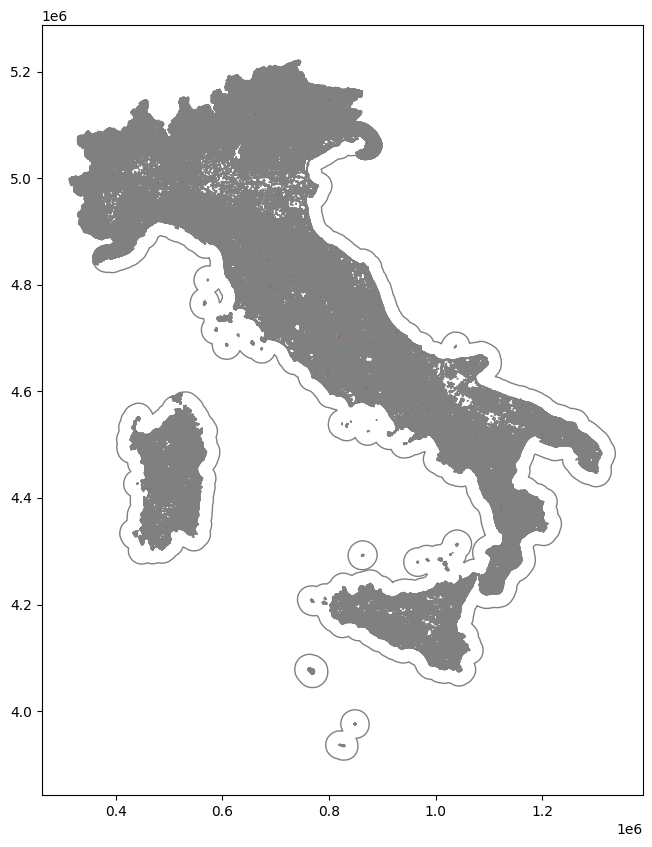

In [42]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

clc.plot(ax=ax, facecolor='none', edgecolor='gray')

gdf.plot(ax=ax, color='red', alpha=0.3, edgecolor='red')

plt.show()

In [49]:
intersect = gpd.overlay(gdf, clc, how="intersection")
intersect

,Ente,Responsabile,Regione,Provincia,GID_2,Comune,Site,Lat,Long,longitude_masked,...,GG_1534,VG_1534,VV_1534,C%_1534,C%_1534_Comune,OBJECTID,CLC18,Shape_Leng,Shape_Area,geometry
0,IZSPLV,CORONA,Piemonte,Torino,ITA.13.6_1,Caselle,Aeroporto,45.193170,7.643180,7.650,...,0,0,30,0.000,0.000,16006,124,12159.412573,3.136028e+06,"POLYGON ((393720.374 5005275.51, 393716.054 50..."
1,IZSPLV,CORONA,Piemonte,Torino,ITA.13.6_1,Caselle,Aeroporto,45.193170,7.643180,7.650,...,0,0,30,0.000,0.000,24905,2111,242420.507328,8.115708e+07,"POLYGON ((393280.399 5005040.339, 393255.147 5..."
2,IZSPLV,CORONA,Liguria,Imperia,ITA.9.2_1,Imperia,IMPERIA,43.885390,8.013910,8.025,...,0,0,16,0.000,0.000,6070,112,26180.411871,3.661924e+06,"POLYGON ((420759.52 4859317.477, 420730.398 48..."
3,IZSPLV,CORONA,Liguria,Imperia,ITA.9.2_1,Imperia,IMPERIA,43.885390,8.013910,8.025,...,0,0,16,0.000,0.000,37707,223,104674.336708,3.417328e+07,"POLYGON ((421087.48 4859586.627, 421083.161 48..."
4,IZSPLV,CORONA,Piemonte,Cuneo,ITA.13.4_1,Alba,Orti c/o cimitero,44.696500,8.020190,8.025,...,0,0,30,0.000,0.000,6910,112,29207.043798,4.775087e+06,"POLYGON ((422667.898 4949673.783, 422663.579 4..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
410,IZSPB,Parisi Antonio,Puglia,Taranto,ITA.2.6_1,Manduria,sito rurale,40.423841,17.630895,17.625,...,0,0,1,0.000,0.000,46609,242,18107.977649,3.076744e+06,"POLYGON ((1232892.792 4510705.28, 1232889.993 ..."
411,IZSPB,Parisi Antonio,Puglia,Brindisi,ITA.2.3_1,Brindisi,Villa privata,40.630998,17.942877,17.950,...,0,0,9,0.000,0.000,600,111,22005.940170,6.744261e+06,"POLYGON ((1256585.417 4536173.884, 1256561.77 ..."
412,IZSPB,Parisi Antonio,Puglia,Brindisi,ITA.2.3_1,Brindisi,Villa privata,40.630998,17.942877,17.950,...,0,0,9,0.000,0.000,3349,112,8641.099048,2.056179e+06,"POLYGON ((1257050.644 4536393.919, 1257046.324..."
413,IZSPB,Parisi Antonio,Puglia,Brindisi,ITA.2.3_1,Brindisi,Villa privata,40.630998,17.942877,17.950,...,0,0,9,0.000,0.000,15856,123,11446.584663,1.485411e+06,"POLYGON ((1257051.652 4536414.443, 1257022.99 ..."


In [50]:
intersect["area_m2"] = intersect.geometry.area
buffer_area = intersect.groupby(["Long","Lat"])["area_m2"].sum().rename("total_area")
intersect = intersect.merge(buffer_area, on=["Long","Lat"])
intersect["percentuale"] = (intersect["area_m2"] / intersect["total_area"]) * 100

In [52]:
intersect = intersect[intersect.is_valid]
intersect

,Ente,Responsabile,Regione,Provincia,GID_2,Comune,Site,Lat,Long,longitude_masked,...,C%_1534,C%_1534_Comune,OBJECTID,CLC18,Shape_Leng,Shape_Area,geometry,area_m2,total_area,percentuale
0,IZSPLV,CORONA,Piemonte,Torino,ITA.13.6_1,Caselle,Aeroporto,45.193170,7.643180,7.650,...,0.000,0.000,16006,124,12159.412573,3.136028e+06,"POLYGON ((393720.374 5005275.51, 393716.054 50...",236789.785140,282289.364149,83.881936
1,IZSPLV,CORONA,Piemonte,Torino,ITA.13.6_1,Caselle,Aeroporto,45.193170,7.643180,7.650,...,0.000,0.000,24905,2111,242420.507328,8.115708e+07,"POLYGON ((393280.399 5005040.339, 393255.147 5...",45499.579009,282289.364149,16.118064
2,IZSPLV,CORONA,Liguria,Imperia,ITA.9.2_1,Imperia,IMPERIA,43.885390,8.013910,8.025,...,0.000,0.000,6070,112,26180.411871,3.661924e+06,"POLYGON ((420759.52 4859317.477, 420730.398 48...",30771.749040,282289.364149,10.900782
3,IZSPLV,CORONA,Liguria,Imperia,ITA.9.2_1,Imperia,IMPERIA,43.885390,8.013910,8.025,...,0.000,0.000,37707,223,104674.336708,3.417328e+07,"POLYGON ((421087.48 4859586.627, 421083.161 48...",251517.615109,282289.364149,89.099218
4,IZSPLV,CORONA,Piemonte,Cuneo,ITA.13.4_1,Alba,Orti c/o cimitero,44.696500,8.020190,8.025,...,0.000,0.000,6910,112,29207.043798,4.775087e+06,"POLYGON ((422667.898 4949673.783, 422663.579 4...",235343.433041,282289.364149,83.369571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
410,IZSPB,Parisi Antonio,Puglia,Taranto,ITA.2.6_1,Manduria,sito rurale,40.423841,17.630895,17.625,...,0.000,0.000,46609,242,18107.977649,3.076744e+06,"POLYGON ((1232892.792 4510705.28, 1232889.993 ...",2461.592579,282289.364149,0.872010
411,IZSPB,Parisi Antonio,Puglia,Brindisi,ITA.2.3_1,Brindisi,Villa privata,40.630998,17.942877,17.950,...,0.000,0.000,600,111,22005.940170,6.744261e+06,"POLYGON ((1256585.417 4536173.884, 1256561.77 ...",190867.734754,282289.364149,67.614214
412,IZSPB,Parisi Antonio,Puglia,Brindisi,ITA.2.3_1,Brindisi,Villa privata,40.630998,17.942877,17.950,...,0.000,0.000,3349,112,8641.099048,2.056179e+06,"POLYGON ((1257050.644 4536393.919, 1257046.324...",88527.595353,282289.364149,31.360585
413,IZSPB,Parisi Antonio,Puglia,Brindisi,ITA.2.3_1,Brindisi,Villa privata,40.630998,17.942877,17.950,...,0.000,0.000,15856,123,11446.584663,1.485411e+06,"POLYGON ((1257051.652 4536414.443, 1257022.99 ...",2894.034042,282289.364149,1.025201


In [53]:
agg_df = (
    intersect.groupby(["Long","Lat"])
    .agg({
        "CLC18": lambda x: ", ".join(map(str, x)),
        "percentuale": lambda x: ", ".join(f"{v:.1f}" for v in x)
    })
    .reset_index()
    .rename(columns={"CLC18": "CLC_18", "percentuale": "CLC_percentage"})
)

In [54]:
agg_df

,Long,Lat,CLC_18,CLC_percentage
0,7.643180,45.193170,"124, 2111","83.9, 16.1"
1,8.013910,43.885390,"112, 223","10.9, 89.1"
2,8.020190,44.696500,"112, 121, 2111","83.4, 16.2, 0.4"
3,8.137000,44.958300,"142, 2111","14.1, 85.9"
4,8.194700,45.583600,"112, 242, 3112, 3113","67.0, 11.3, 0.1, 21.5"
...,...,...,...,...
157,17.251351,40.531898,"223, 231","83.6, 16.4"
158,17.268182,40.463595,"111, 112","98.9, 1.1"
159,17.630895,40.423841,"223, 242","99.1, 0.9"
160,17.942877,40.630998,"111, 112, 123","67.6, 31.4, 1.0"


In [55]:
df.columns

Index(['Ente', 'Responsabile', 'Regione', 'Provincia', 'GID_2', 'Comune',
       'Site', 'Lat', 'Long', 'longitude_masked', 'latitude_masked',
       'Anno campionamento', 'Mese di campionamento', 'Metodo di Cattura',
       'Stadio Genotipizzato', 'N_1016', 'GG_1016', 'VG_1016', 'VV_1016',
       'G%_1016', 'G%_1016_Comune', 'N_1534', 'GG_1534', 'VG_1534', 'VV_1534',
       'C%_1534', 'C%_1534_Comune'],
      dtype='object')

In [56]:
# Join finale sul Comune
final_df = pd.merge(df, agg_df, on=["Long","Lat"], how='left')
final_df

,Ente,Responsabile,Regione,Provincia,GID_2,Comune,Site,Lat,Long,longitude_masked,...,G%_1016,G%_1016_Comune,N_1534,GG_1534,VG_1534,VV_1534,C%_1534,C%_1534_Comune,CLC_18,CLC_percentage
0,IZSPLV,CORONA,Piemonte,Torino,ITA.13.6_1,Caselle,Aeroporto,45.193170,7.643180,7.650,...,0.000,0.000,30,0,0,30,0.000,0.000,"124, 2111","83.9, 16.1"
1,IZSPLV,CORONA,Liguria,Imperia,ITA.9.2_1,Imperia,IMPERIA,43.885390,8.013910,8.025,...,0.000,0.000,16,0,0,16,0.000,0.000,"112, 223","10.9, 89.1"
2,IZSPLV,CORONA,Piemonte,Cuneo,ITA.13.4_1,Alba,Orti c/o cimitero,44.696500,8.020190,8.025,...,0.067,0.067,30,0,0,30,0.000,0.000,"112, 121, 2111","83.4, 16.2, 0.4"
3,IZSPLV,CORONA,Piemonte,Asti,ITA.13.2_1,Asti,fraz. Mombarone,44.958300,8.137000,8.125,...,0.000,0.000,8,0,0,8,0.000,0.000,"142, 2111","14.1, 85.9"
4,IZSPLV,CORONA,Piemonte,Biella,ITA.13.3_1,Lessona,Villa Boggio,45.583600,8.194700,8.200,...,0.000,0.000,12,0,0,12,0.000,0.000,"112, 242, 3112, 3113","67.0, 11.3, 0.1, 21.5"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,IZSPB,Parisi Antonio,Puglia,Taranto,ITA.2.6_1,Taranto,sito rurale,40.531898,17.251351,17.250,...,0.000,0.292,1,0,0,1,0.000,0.000,"223, 231","83.6, 16.4"
158,IZSPB,Parisi Antonio,Puglia,Taranto,ITA.2.6_1,Taranto,Villa privata,40.463595,17.268182,17.275,...,0.350,0.292,10,0,0,10,0.000,0.000,"111, 112","98.9, 1.1"
159,IZSPB,Parisi Antonio,Puglia,Taranto,ITA.2.6_1,Manduria,sito rurale,40.423841,17.630895,17.625,...,0.000,0.292,1,0,0,1,0.000,0.000,"223, 242","99.1, 0.9"
160,IZSPB,Parisi Antonio,Puglia,Brindisi,ITA.2.3_1,Brindisi,Villa privata,40.630998,17.942877,17.950,...,0.333,0.333,9,0,0,9,0.000,0.000,"111, 112, 123","67.6, 31.4, 1.0"


In [57]:
final_df.to_csv("../Meta/albo_geno_masked.csv")

-----------------------------------

### ERA5 Temperature

In [140]:
import cdsapi

c = cdsapi.Client()

c.retrieve(
    'reanalysis-era5-single-levels',
    {
        'product_type': 'reanalysis',
        'variable': '2m_temperature',
        'year': '2024',
        'month': [f'{i:02d}' for i in range(1, 13)],
        'day': [f'{i:02d}' for i in range(1, 32)],
        'time': [f'{i:02d}:00' for i in range(24)],
        'format': 'netcdf',
        'area': [47, 6, 36, 18],  # [N, W, S, E] → esempio: Italia
        'grid': [0.25, 0.25],     # risoluzione 0.25° (~25 km)
    },
    'era5_temp_2024.nc'
)


2025-06-30 15:16:31,971 WARNING [2025-06-23T00:00:00] Scheduled System Session affecting Service reliability - 30 June 2025. Please follow status [here](https://status.ecmwf.int/) or in our [forum](https://forum.ecmwf.int/t/scheduled-maintenance-of-the-cloud-infrastructure-on-30-june-2025/13598)
2025-06-30 15:16:31,972 INFO [2025-06-16T00:00:00] CC-BY licence to replace Licence to use Copernicus Products on 02 July 2025. More information available [here](https://forum.ecmwf.int/t/cc-by-licence-to-replace-licence-to-use-copernicus-products-on-02-july-2025/13464)
2025-06-30 15:16:31,973 INFO [2025-06-10T00:00:00] To improve our C3S service, we need to hear from you! Please complete this very short [survey](https://confluence.ecmwf.int/x/E7uBEQ/). Thank you.
2025-06-30 15:16:31,973 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-06-30 15:16:32,791 INFO Request ID is 797a517b-df29-4595-b806-36eacafda6d9
2025-06

7ec633fc5f02f994d4f7fd3f603826a3.nc:   0%|          | 0.00/37.6M [00:00<?, ?B/s]

'era5_temp_2024.nc'

In [59]:
lonlatdf = pd.read_csv("/home/randomx/lat_lon.csv", sep = ",")
lonlatdf

,Lat,Long
0,42.363691,13.354530
1,42.654708,13.710894
2,42.436400,14.177920
3,42.413718,14.202405
4,42.050162,14.730420
...,...,...
157,45.070990,11.771230
158,45.349860,11.956360
159,46.138150,12.197750
160,45.652490,12.197450


In [60]:
import xarray as xr
import pandas as pd

ds = xr.open_dataset("era5_temp_2024.nc")

temp_K = ds['t2m']  
temp_C = temp_K.mean(dim='valid_time') - 273.15

# Lista di coordinate da interrogare
coords = list(zip(lonlatdf["Lat"], lonlatdf["Long"]))
results = []

for lat, lon in coords:
    value = temp_C.sel(latitude=lat, longitude=lon, method='nearest').values.item()
    results.append({"lat": lat, "lon": lon, "temp_C_2024": round(value, 2)})

df = pd.DataFrame(results)
print(df)

           lat        lon  temp_C_2024
0    42.363691  13.354530        11.91
1    42.654708  13.710894        15.60
2    42.436400  14.177920        17.36
3    42.413718  14.202405        17.36
4    42.050162  14.730420        17.39
..         ...        ...          ...
157  45.070990  11.771230        15.17
158  45.349860  11.956360        15.23
159  46.138150  12.197750         7.83
160  45.652490  12.197450        14.85
161  45.498730  12.335550        15.71

[162 rows x 3 columns]


In [61]:
df.to_csv("ERA5_temperature_mean.csv")

----------------------

### Istat Demografia

In [171]:
import geopandas as gpd
import pandas as pd
import glob
import os

shp_files = glob.glob("/media/randomx/Data/Gis/shape/pop_ita/*/SHP/*.shp")

gdf_list = [gpd.read_file(shp) for shp in shp_files]

merged_gdf = gpd.GeoDataFrame(pd.concat(gdf_list, ignore_index=True))


output_path = "/media/randomx/Data/Gis/shape/pop_ita/merged_pop.shp"
merged_gdf.to_file(output_path)

print(f"Shapefile unito salvato in: {output_path}")

/home/randomx/anaconda3/envs/pyenv/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 113587778.067 of field SHAPE_Area of feature 106638 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/randomx/anaconda3/envs/pyenv/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 152428477.94400001 of field SHAPE_Area of feature 603710 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/randomx/anaconda3/envs/pyenv/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 175198149.609 of field SHAPE_Area of feature 603711 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/randomx/anaconda3/envs/pyenv/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 175967385.028 of field SHAPE_Area of feature 604551 not successfully written. Possibly due to too larger number 

Shapefile unito salvato in: /media/randomx/Data/Gis/shape/pop_ita/merged_pop.shp


/home/randomx/anaconda3/envs/pyenv/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 146484999.68900001 of field SHAPE_Area of feature 642817 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/randomx/anaconda3/envs/pyenv/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 181900341.09799999 of field SHAPE_Area of feature 710714 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/randomx/anaconda3/envs/pyenv/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 106195244.807 of field SHAPE_Area of feature 731789 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/randomx/anaconda3/envs/pyenv/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 181539679.96700001 of field SHAPE_Area of feature 747151 not successfully written. Possibly due to too larg

In [28]:
df = pd.read_csv("../Meta/albo_geno_masked_elg.csv")
df

,Unnamed: 0,Site,Comune,N_1016,GG_1016,VG_1016,VV_1016,G%_1016,N_1534,GG_1534,...,Provincia,Anno campionamento,Lat,Long,longitude_masked,latitude_masked,Mese di campionamento,Metodo di Cattura,Stadio Genotipizzato,GID_2
0,0,Aeroporto,CASELLE,30,0,0,30,0.000,30,0,...,Torino,2024.0,45.193170,7.643180,7.650,45.200,settembre,ovitrappola,adulto,ITA.13.6_1
1,1,IMPERIA,IMPERIA,18,0,0,18,0.000,16,0,...,Imperia,2024.0,43.885390,8.013910,8.025,43.875,NaN,NaN,adulto,ITA.9.2_1
2,2,Orti c/o cimitero,ALBA,30,0,4,26,0.067,30,0,...,Cuneo,2024.0,44.696500,8.020190,8.025,44.700,agosto-settembre,CDC-CO2,adulto,ITA.13.4_1
3,3,fraz. Mombarone,ASTI,8,0,0,8,0.000,8,0,...,Asti,2024.0,44.958300,8.137000,8.125,44.950,agosto-settembre,CDC-CO2,adulto,ITA.13.2_1
4,4,Villa Boggio,LESSONA,12,0,0,12,0.000,12,0,...,Biella,2024.0,45.583600,8.194700,8.200,45.575,agosto-settembre,CDC-CO2,adulto,ITA.13.3_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,157,sito rurale,Taranto,1,0,0,1,0.000,1,0,...,Taranto,2024.0,40.531898,17.251351,17.250,40.525,luglio,Sì,Adulti,ITA.2.6_1
158,158,Villa privata,Taranto,10,2,3,5,0.350,10,0,...,Taranto,2025.0,40.463595,17.268182,17.275,40.475,maggio,Sì,Adulti,ITA.2.6_1
159,159,sito rurale,Manduria,1,0,0,1,0.000,1,0,...,Taranto,2024.0,40.423841,17.630895,17.625,40.425,luglio,Sì,Adulti,ITA.2.6_1
160,160,Villa privata,Brindisi,9,1,4,4,0.333,9,0,...,Brindisi,2025.0,40.630998,17.942877,17.950,40.625,maggio,Sì,Adulti,ITA.2.3_1


In [29]:
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.Long, df.Lat), crs="EPSG:4326")

gdf = gdf.to_crs(epsg=32632)  # Usa l'EPSG corretto per la tua area

In [30]:
gdf["geometry"] = gdf.buffer(300)

In [31]:
dem = gpd.read_file("/media/randomx/Data/Gis/shape/pop_ita/merged_pop.shp")
dem = dem.to_crs(gdf.crs)

In [32]:
dem.crs

<Projected CRS: EPSG:32632>
Name: WGS 84 / UTM zone 32N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 6°E and 12°E, northern hemisphere between equator and 84°N, onshore and offshore. Algeria. Austria. Cameroon. Denmark. Equatorial Guinea. France. Gabon. Germany. Italy. Libya. Liechtenstein. Monaco. Netherlands. Niger. Nigeria. Norway. Sao Tome and Principe. Svalbard. Sweden. Switzerland. Tunisia. Vatican City State.
- bounds: (6.0, 0.0, 12.0, 84.0)
Coordinate Operation:
- name: UTM zone 32N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

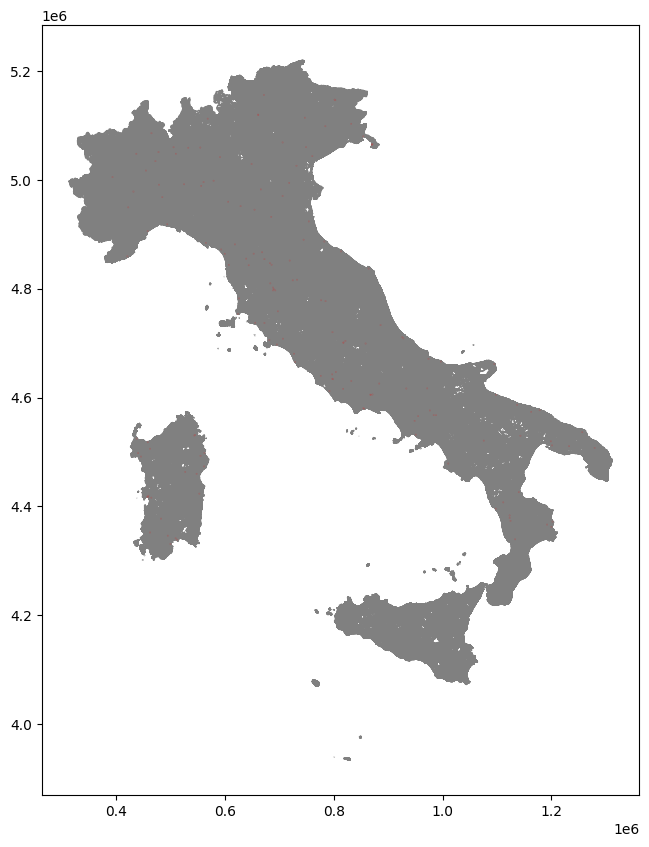

In [33]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

dem.plot(ax=ax, facecolor='none', edgecolor='gray')

gdf.plot(ax=ax, color='red', alpha=0.3, edgecolor='red')

plt.show()


In [34]:
intersect = gpd.overlay(gdf, dem, how="intersection")
intersect

,Unnamed: 0,Site,Comune,N_1016,GG_1016,VG_1016,VV_1016,G%_1016,N_1534,GG_1534,...,COM_ASC1,COM_ASC2,COM_ASC3,POP21,FAM21,ABI21,EDI21,SHAPE_Leng,SHAPE_Area,geometry
0,0,Aeroporto,CASELLE,30,0,0,30,0.00,30,0,...,0,0,0,37,11,21,13,11627.271718,1.219600e+06,"POLYGON ((393255.147 5005055.474, 393231.5 500..."
1,0,Aeroporto,CASELLE,30,0,0,30,0.00,30,0,...,0,0,0,0,0,0,0,6283.350021,2.004515e+06,"POLYGON ((393720.374 5005275.51, 393716.054 50..."
2,0,Aeroporto,CASELLE,30,0,0,30,0.00,30,0,...,0,0,0,0,0,0,0,1091.633591,7.544117e+03,"POLYGON ((393255.147 5005554.356, 393264.077 5..."
3,0,Aeroporto,CASELLE,30,0,0,30,0.00,30,0,...,0,0,0,25,10,11,3,1285.788324,2.203077e+04,"POLYGON ((393307.013 5005027.751, 393280.399 5..."
4,1,IMPERIA,IMPERIA,18,0,0,18,0.00,16,0,...,0,0,0,679,306,431,120,3655.180743,3.542598e+05,"POLYGON ((421087.48 4859586.627, 421083.161 48..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2001,161,Villa privata,Lecce,29,0,11,18,0.19,29,5,...,75035001,0,0,0,0,0,0,155.534707,1.342222e+03,"POLYGON ((1279443.293 4507390.622, 1279443.416..."
2002,161,Villa privata,Lecce,29,0,11,18,0.19,29,5,...,75035001,0,0,0,0,0,0,164.018379,1.299832e+03,"POLYGON ((1279342.984 4507379.925, 1279349.232..."
2003,161,Villa privata,Lecce,29,0,11,18,0.19,29,5,...,75035001,0,0,16,11,13,1,227.516013,3.289688e+03,"POLYGON ((1279631.229 4507348.322, 1279613.239..."
2004,161,Villa privata,Lecce,29,0,11,18,0.19,29,5,...,75035001,0,0,0,0,0,0,82.534454,3.461075e+02,"POLYGON ((1279404.597 4507674.521, 1279391.262..."


In [35]:
intersect["area_m2"] = intersect.geometry.area

In [36]:
intersect["pop_pesata"] = intersect["POP21"] * (intersect["area_m2"] / intersect["SHAPE_Area"])

In [37]:
intersect

,Unnamed: 0,Site,Comune,N_1016,GG_1016,VG_1016,VV_1016,G%_1016,N_1534,GG_1534,...,COM_ASC3,POP21,FAM21,ABI21,EDI21,SHAPE_Leng,SHAPE_Area,geometry,area_m2,pop_pesata
0,0,Aeroporto,CASELLE,30,0,0,30,0.00,30,0,...,0,37,11,21,13,11627.271718,1.219600e+06,"POLYGON ((393255.147 5005055.474, 393231.5 500...",50045.008933,1.518256
1,0,Aeroporto,CASELLE,30,0,0,30,0.00,30,0,...,0,0,0,0,0,6283.350021,2.004515e+06,"POLYGON ((393720.374 5005275.51, 393716.054 50...",215910.506378,0.000000
2,0,Aeroporto,CASELLE,30,0,0,30,0.00,30,0,...,0,0,0,0,0,1091.633591,7.544117e+03,"POLYGON ((393255.147 5005554.356, 393264.077 5...",4318.496660,0.000000
3,0,Aeroporto,CASELLE,30,0,0,30,0.00,30,0,...,0,25,10,11,3,1285.788324,2.203077e+04,"POLYGON ((393307.013 5005027.751, 393280.399 5...",12015.352178,13.634737
4,1,IMPERIA,IMPERIA,18,0,0,18,0.00,16,0,...,0,679,306,431,120,3655.180743,3.542598e+05,"POLYGON ((421087.48 4859586.627, 421083.161 48...",185541.138788,355.621541
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2001,161,Villa privata,Lecce,29,0,11,18,0.19,29,5,...,0,0,0,0,0,155.534707,1.342222e+03,"POLYGON ((1279443.293 4507390.622, 1279443.416...",1342.221837,0.000000
2002,161,Villa privata,Lecce,29,0,11,18,0.19,29,5,...,0,0,0,0,0,164.018379,1.299832e+03,"POLYGON ((1279342.984 4507379.925, 1279349.232...",1084.961662,0.000000
2003,161,Villa privata,Lecce,29,0,11,18,0.19,29,5,...,0,16,11,13,1,227.516013,3.289688e+03,"POLYGON ((1279631.229 4507348.322, 1279613.239...",3289.688004,16.000000
2004,161,Villa privata,Lecce,29,0,11,18,0.19,29,5,...,0,0,0,0,0,82.534454,3.461075e+02,"POLYGON ((1279404.597 4507674.521, 1279391.262...",346.107539,0.000000


In [40]:
gdf["Unnamed: 0"] = gdf.index

In [41]:
pop_per_buffer = (
    intersect.groupby("Unnamed: 0")["pop_pesata"]
    .sum()
    .reset_index()
    .rename(columns={"pop_pesata": "pop_totale_300m"})
)

In [42]:
pop_per_buffer

,Unnamed: 0,pop_totale_300m
0,0,15.152994
1,1,623.477101
2,2,220.623395
3,3,16.093468
4,4,270.841482
...,...,...
157,157,0.274124
158,158,6480.716101
159,159,2.533382
160,160,1018.745732


In [44]:
gdf_out = gdf.merge(pop_per_buffer, on=["Unnamed: 0"])

In [45]:
gdf_out

,Unnamed: 0,Site,Comune,N_1016,GG_1016,VG_1016,VV_1016,G%_1016,N_1534,GG_1534,...,Long,longitude_masked,latitude_masked,Mese di campionamento,Metodo di Cattura,Stadio Genotipizzato,GID_2,geometry,ID,pop_totale_300m
0,0,Aeroporto,CASELLE,30,0,0,30,0.000,30,0,...,7.643180,7.650,45.200,settembre,ovitrappola,adulto,ITA.13.6_1,"POLYGON ((393721.818 5005304.915, 393720.374 5...",0,15.152994
1,1,IMPERIA,IMPERIA,18,0,0,18,0.000,16,0,...,8.013910,8.025,43.875,NaN,NaN,adulto,ITA.9.2_1,"POLYGON ((421088.925 4859616.032, 421087.48 48...",1,623.477101
2,2,Orti c/o cimitero,ALBA,30,0,4,26,0.067,30,0,...,8.020190,8.025,44.700,agosto-settembre,CDC-CO2,adulto,ITA.13.4_1,"POLYGON ((422669.343 4949703.189, 422667.898 4...",2,220.623395
3,3,fraz. Mombarone,ASTI,8,0,0,8,0.000,8,0,...,8.137000,8.125,44.950,agosto-settembre,CDC-CO2,adulto,ITA.13.2_1,"POLYGON ((432233.072 4978680.302, 432231.628 4...",3,16.093468
4,4,Villa Boggio,LESSONA,12,0,0,12,0.000,12,0,...,8.194700,8.200,45.575,agosto-settembre,CDC-CO2,adulto,ITA.13.3_1,"POLYGON ((437477.702 5048099.643, 437476.257 5...",4,270.841482
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,157,sito rurale,Taranto,1,0,0,1,0.000,1,0,...,17.251351,17.250,40.525,luglio,Sì,Adulti,ITA.2.6_1,"POLYGON ((1199511.644 4519638.367, 1199510.199...",157,0.274124
158,158,Villa privata,Taranto,10,2,3,5,0.350,10,0,...,17.268182,17.275,40.475,maggio,Sì,Adulti,ITA.2.6_1,"POLYGON ((1201656.09 4512179.173, 1201654.645 ...",158,6480.716101
159,159,sito rurale,Manduria,1,0,0,1,0.000,1,0,...,17.630895,17.625,40.425,luglio,Sì,Adulti,ITA.2.6_1,"POLYGON ((1232893.931 4510728.455, 1232892.486...",159,2.533382
160,160,Villa privata,Brindisi,9,1,4,4,0.333,9,0,...,17.942877,17.950,40.625,maggio,Sì,Adulti,ITA.2.3_1,"POLYGON ((1257052.088 4536423.325, 1257050.644...",160,1018.745732


In [46]:
gdf_out.columns

Index(['Unnamed: 0', 'Site', 'Comune', 'N_1016', 'GG_1016', 'VG_1016',
       'VV_1016', 'G%_1016', 'N_1534', 'GG_1534', 'VG_1534', 'VV_1534',
       'C%_1534', 'Ente', 'Responsabile', 'Regione', 'Provincia',
       'Anno campionamento', 'Lat', 'Long', 'longitude_masked',
       'latitude_masked', 'Mese di campionamento', 'Metodo di Cattura',
       'Stadio Genotipizzato', 'GID_2', 'geometry', 'ID', 'pop_totale_300m'],
      dtype='object')

In [47]:
gdf_out.to_csv("../Meta/albo_geno_masked.csv")